# Unsupervised models: K-Means and One-Class SVM

This notebook follows a very specific setup.

- **train** = rows where `fraud == "unknown"`
- **test** = rows where `fraud == "fraud"`
- the label is only used to split the data and to check the results later
- both models are trained **without** the label in the input features

So this is not a regular supervised classification setup.

What I want to check here is pretty simple:

1. does the `unknown` set show any natural structure on its own?
2. after learning from the `unknown` set, do the `fraud` rows look abnormal enough to get flagged?

For K-Means, I keep `k=3` as requested.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from scipy import sparse

from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import OneClassSVM

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

## 1. Config

In [2]:
DATA_PATH = "fraud_data_encoded_v2.csv"

LABEL_COL = "fraud"
TRAIN_LABEL = "unknown"
TEST_LABEL = "fraud"

RANDOM_STATE = 42
KMEANS_K = 3
KMEANS_DISTANCE_QUANTILE = 0.99

OCSVM_KERNEL = "rbf"
OCSVM_NU = 0.05
OCSVM_GAMMA = "scale"

MAX_CATEGORICAL_LEVELS = 30
MAX_CATEGORICAL_RATIO = 0.05
MAX_MISSING_RATE = 0.98
SVD_MAX_COMPONENTS = 50

FLAG_MAPPINGS = {
    "ocr_tampering_flag": {"yes": 1, "no": 0},
    "front_liveness_fakeprint": {"true": 1, "false": 0},
    "back_liveness_fakeprint": {"true": 1, "false": 0},
    "front_object_liveness": {"success": 1, "failure": 0},
    "back_object_liveness": {"success": 1, "failure": 0},
    "liveness3d_object_liveness": {"success": 1, "failure": 0},
}

NUMERIC_COLS = ["tampering_flag", "year", "month", "day"]

DROP_NAME_KEYWORDS = [
    "uuid",
    "hash",
    "embedding",
    "image",
    "img",
    "photo",
    "avatar",
    "base64",
    "filepath",
    "filename",
    "sessionid",
]

MANUAL_DROP_COLS = [
    "tokenid",
    "ocr_cccd",
    "finger_print",
    "client_session",
    "facecompare_uuid",
    "liveness3d_uuid",
    "geolite_ipaddress",
]

## 2. Helpers

Nothing fancy here. I just keep the preprocessing and feature selection in a few small functions so the notebook stays readable.

In [ ]:
def normalize_text(series):
    return series.astype("string").str.strip().str.lower()


def safe_map(series, mapping):
    return normalize_text(series).map(mapping)


def preprocess_data(df):
    data = df.copy()

    for col, mapping in FLAG_MAPPINGS.items():
        if col in data.columns:
            data[col] = safe_map(data[col], mapping)

    for col in NUMERIC_COLS:
        if col in data.columns:
            data[col] = pd.to_numeric(data[col], errors="coerce")

    if LABEL_COL in data.columns:
        data["target"] = normalize_text(data[LABEL_COL]).map({
            TRAIN_LABEL: 0,
            TEST_LABEL: 1,
        })

    return data


def pick_feature_columns(df, label_col):
    keep_cols = []
    dropped_rows = []

    for col in df.columns:
        if col in {label_col, "target"}:
            dropped_rows.append({"column": col, "reason": "label"})
            continue

        series = df[col]
        nunique = series.nunique(dropna=False)
        missing_rate = series.isna().mean()
        unique_ratio = nunique / len(df)

        if col in MANUAL_DROP_COLS:
            dropped_rows.append({"column": col, "reason": "manual_drop"})
            continue

        if any(keyword in col.lower() for keyword in DROP_NAME_KEYWORDS):
            dropped_rows.append({"column": col, "reason": "name_rule"})
            continue

        if nunique <= 1:
            dropped_rows.append({"column": col, "reason": "single_value"})
            continue

        if missing_rate >= MAX_MISSING_RATE:
            dropped_rows.append({"column": col, "reason": "too_many_missing"})
            continue

        if pd.api.types.is_numeric_dtype(series):
            keep_cols.append(col)
            continue

        if nunique <= MAX_CATEGORICAL_LEVELS and unique_ratio <= MAX_CATEGORICAL_RATIO:
            keep_cols.append(col)
        else:
            dropped_rows.append({"column": col, "reason": "high_cardinality_text"})

    dropped_df = pd.DataFrame(dropped_rows).sort_values(["reason", "column"]).reset_index(drop=True)
    return keep_cols, dropped_df


def make_preprocessor(df, feature_cols):
    numeric_cols = [col for col in feature_cols if pd.api.types.is_numeric_dtype(df[col])]
    categorical_cols = [col for col in feature_cols if col not in numeric_cols]

    numeric_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])

    categorical_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_pipe, numeric_cols),
            ("cat", categorical_pipe, categorical_cols),
        ],
        remainder="drop",
    )

    return preprocessor, numeric_cols, categorical_cols


def make_dense_representation(X_train, X_test, max_components=50, random_state=42):
    if sparse.issparse(X_train):
        max_valid = min(X_train.shape[0] - 1, X_train.shape[1] - 1, max_components)

        if max_valid >= 2:
            svd = TruncatedSVD(n_components=max_valid, random_state=random_state)
            X_train_dense = svd.fit_transform(X_train)
            X_test_dense = svd.transform(X_test)

            scaler = StandardScaler()
            X_train_dense = scaler.fit_transform(X_train_dense)
            X_test_dense = scaler.transform(X_test_dense)

            info = {
                "used_svd": True,
                "n_components": max_valid,
                "input_dim": X_train.shape[1],
                "output_dim": X_train_dense.shape[1],
            }
            return X_train_dense, X_test_dense, info

        X_train_dense = X_train.toarray()
        X_test_dense = X_test.toarray()
    else:
        X_train_dense = np.asarray(X_train)
        X_test_dense = np.asarray(X_test)

    scaler = StandardScaler()
    X_train_dense = scaler.fit_transform(X_train_dense)
    X_test_dense = scaler.transform(X_test_dense)

    info = {
        "used_svd": False,
        "n_components": None,
        "input_dim": X_train_dense.shape[1],
        "output_dim": X_train_dense.shape[1],
    }
    return X_train_dense, X_test_dense, info


def plot_pca_clusters(X, cluster_labels, title):
    if X.shape[1] < 2:
        print("PCA plot skipped because the feature space is less than 2D.")
        return

    pca = PCA(n_components=2, random_state=RANDOM_STATE)
    coords = pca.fit_transform(X)

    plt.figure(figsize=(8, 5))
    plt.scatter(coords[:, 0], coords[:, 1], c=cluster_labels, s=14, alpha=0.75)
    plt.title(title)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.tight_layout()
    plt.show()


def distance_summary(train_dist, test_dist, quantiles=(0.95, 0.99, 1.00)):
    rows = []

    for q in quantiles:
        if q < 1.0:
            threshold = float(np.quantile(train_dist, q))
            label = f"q={q:.2f}"
        else:
            threshold = float(np.max(train_dist))
            label = "max(train)"

        train_flag = train_dist > threshold
        test_flag = test_dist > threshold

        rows.append({
            "threshold_rule": label,
            "threshold_value": threshold,
            "train_flagged_rate": float(train_flag.mean()),
            "test_flagged_rate": float(test_flag.mean()),
        })

    return pd.DataFrame(rows)


def show_hist(train_values, test_values, title, xlabel):
    plt.figure(figsize=(8, 4))
    plt.hist(train_values, bins=40, alpha=0.7, label="train: unknown")
    plt.hist(test_values, bins=40, alpha=0.7, label="test: fraud")
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Count")
    plt.legend()
    plt.tight_layout()
    plt.show()

## 3. Load the data and split it the way we agreed

The split is fully label-based, but the label does **not** go into the model features.

- train = all `unknown`
- test = all `fraud`

In [4]:
df_raw = pd.read_csv(DATA_PATH)
df = preprocess_data(df_raw)

label_counts = normalize_text(df[LABEL_COL]).value_counts(dropna=False).rename_axis(LABEL_COL).reset_index(name="count")
display(label_counts)

train_mask = normalize_text(df[LABEL_COL]) == TRAIN_LABEL
test_mask = normalize_text(df[LABEL_COL]) == TEST_LABEL

train_df = df.loc[train_mask].copy()
test_df = df.loc[test_mask].copy()

print(f"Full data shape  : {df.shape}")
print(f"Train shape      : {train_df.shape}  (all '{TRAIN_LABEL}')")
print(f"Test shape       : {test_df.shape}  (all '{TEST_LABEL}')")

,fraud,count
0,unknown,31293
1,fraud,39


Full data shape  : (31332, 46)
Train shape      : (31293, 46)  (all 'unknown')
Test shape       : (39, 46)  (all 'fraud')


## 4. Pick a usable feature set

I do **not** want to throw raw IDs, UUIDs, hash-like columns, image paths, or huge text-cardinality columns straight into the models.

So the feature selection below keeps things fairly conservative:

- keep numeric columns
- keep small categorical columns
- drop the label
- drop obviously leak-prone or ID-like fields
- drop columns that are nearly all missing

In [5]:
feature_cols, dropped_feature_info = pick_feature_columns(train_df, LABEL_COL)

print(f"Columns kept for modeling: {len(feature_cols)}")
print(f"Columns dropped         : {len(dropped_feature_info)}")

display(pd.DataFrame({"feature_col": feature_cols}).head(50))
display(dropped_feature_info.head(50))

if len(feature_cols) == 0:
    raise ValueError("No feature columns left after filtering. Please loosen the feature selection rules.")

Columns kept for modeling: 19
Columns dropped         : 27


,feature_col
0,req_path
1,req_timestamplog
2,res_timestamplog
3,ocr_tampering_flag
4,month
5,day
6,front_liveness_fakeprint
7,front_object_liveness
8,liveness_timestamplog_front
9,liveness_timestamplog_back


,column,reason
0,city,high_cardinality_text
1,flag_123456,high_cardinality_text
2,ipaddress,high_cardinality_text
3,ma_may,high_cardinality_text
4,os_version,high_cardinality_text
5,fraud,label
6,target,label
7,client_session,manual_drop
8,facecompare_uuid,manual_drop
9,finger_print,manual_drop


In [6]:
X_train_df = train_df[feature_cols].copy()
X_test_df = test_df[feature_cols].copy()

preprocessor, numeric_cols, categorical_cols = make_preprocessor(train_df, feature_cols)

X_train_pre = preprocessor.fit_transform(X_train_df)
X_test_pre = preprocessor.transform(X_test_df)

X_train_model, X_test_model, dim_info = make_dense_representation(
    X_train_pre,
    X_test_pre,
    max_components=SVD_MAX_COMPONENTS,
    random_state=RANDOM_STATE,
)

print("Numeric columns     :", len(numeric_cols))
print("Categorical columns :", len(categorical_cols))
print("Matrix info         :", dim_info)
print("Final train shape   :", X_train_model.shape)
print("Final test shape    :", X_test_model.shape)

Numeric columns     : 17
Categorical columns : 2
Matrix info         : {'used_svd': False, 'n_components': None, 'input_dim': 23, 'output_dim': 23}
Final train shape   : (31293, 23)
Final test shape    : (39, 23)


## 5. K-Means (`k=3`)

Here I use K-Means in two ways:

1. **cluster view on the train set**  
   Just to see whether the `unknown` rows naturally break into a few groups.

2. **distance-to-centroid anomaly rule**  
   K-Means is not an anomaly detector by itself, so I turn the nearest-centroid distance into a simple anomaly score:
   - fit K-Means on the train set
   - compute distance to the nearest centroid
   - use train-distance quantiles as thresholds
   - check how many fraud rows land outside the train pattern

,cluster,count,ratio
0,0,21997,0.7029
1,1,6428,0.2054
2,2,2868,0.0916


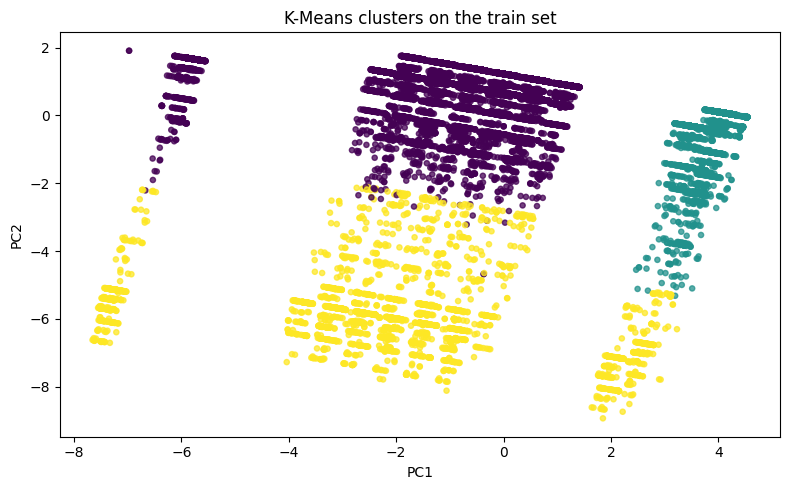

In [7]:
kmeans = KMeans(n_clusters=KMEANS_K, random_state=RANDOM_STATE, n_init=20)
kmeans.fit(X_train_model)

train_clusters = kmeans.labels_
train_cluster_distances = kmeans.transform(X_train_model)
test_cluster_distances = kmeans.transform(X_test_model)

train_nearest_dist = train_cluster_distances.min(axis=1)
test_nearest_dist = test_cluster_distances.min(axis=1)

cluster_counts = pd.Series(train_clusters).value_counts().sort_index().rename_axis("cluster").reset_index(name="count")
cluster_counts["ratio"] = (cluster_counts["count"] / len(train_clusters)).round(4)

display(cluster_counts)
plot_pca_clusters(X_train_model, train_clusters, "K-Means clusters on the train set")

,threshold_rule,threshold_value,train_flagged_rate,test_flagged_rate
0,q=0.95,6.851866,0.050011,1.0
1,q=0.99,7.863067,0.010002,1.0
2,max(train),170.763392,0.000000,0.0


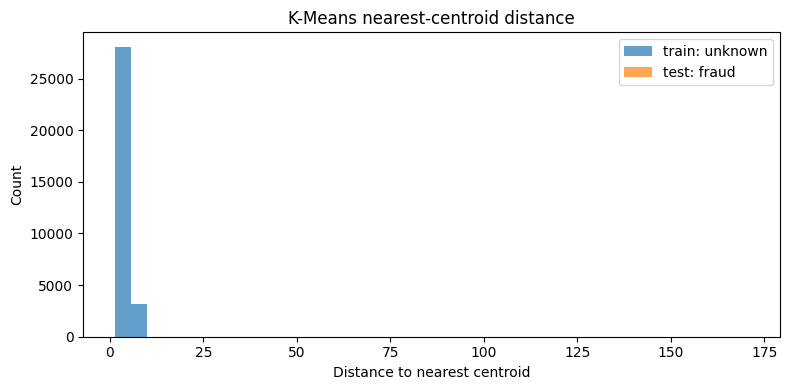

In [8]:
kmeans_threshold_table = distance_summary(
    train_nearest_dist,
    test_nearest_dist,
    quantiles=(0.95, KMEANS_DISTANCE_QUANTILE, 1.00),
)

display(kmeans_threshold_table)

show_hist(
    train_nearest_dist,
    test_nearest_dist,
    title="K-Means nearest-centroid distance",
    xlabel="Distance to nearest centroid",
)

In [9]:
default_kmeans_threshold = float(np.quantile(train_nearest_dist, KMEANS_DISTANCE_QUANTILE))

kmeans_train_pred = (train_nearest_dist > default_kmeans_threshold).astype(int)
kmeans_test_pred = (test_nearest_dist > default_kmeans_threshold).astype(int)

kmeans_result = pd.DataFrame({
    "model": ["KMeans"],
    "rule": [f"nearest distance > train q={KMEANS_DISTANCE_QUANTILE:.2f}"],
    "train_flagged_rate": [kmeans_train_pred.mean()],
    "test_flagged_rate": [kmeans_test_pred.mean()],
})

display(kmeans_result)

,model,rule,train_flagged_rate,test_flagged_rate
0,KMeans,nearest distance > train q=0.99,0.010002,1.0


In [10]:
profile_candidates = [col for col in numeric_cols if col in train_df.columns]

if len(profile_candidates) > 0:
    top_profile_cols = (
        train_df[profile_candidates]
        .var(numeric_only=True)
        .sort_values(ascending=False)
        .head(10)
        .index
        .tolist()
    )

    cluster_profile = (
        train_df.assign(kmeans_cluster=train_clusters)
        .groupby("kmeans_cluster")[top_profile_cols]
        .mean()
        .round(3)
    )

    print("A quick numeric profile by cluster:")
    display(cluster_profile)
else:
    print("No numeric columns available for a quick cluster profile.")

A quick numeric profile by cluster:


,liveness_timestamplog_back,req_timestamplog,res_timestamplog,liveness_timestamplog_front,liveness3d_timestamplog,facecompare_timestamplog,day,latitude,longitude,tampering_flag
kmeans_cluster,,,,,,,,,,
0,1.762251e+12,1.762251e+12,1.762251e+12,1.762251e+12,1.762251e+12,1.762251e+12,6.192,15.022,106.382,0.121
1,1.762934e+12,1.762934e+12,1.762934e+12,1.762934e+12,1.762934e+12,1.762934e+12,12.072,15.269,106.382,0.136
2,1.762308e+12,1.762308e+12,1.762308e+12,1.762308e+12,1.762308e+12,1.762308e+12,8.832,17.016,106.194,1.000


## 6. One-Class SVM

This one is a more direct anomaly model.

- fit on the `unknown` rows only
- learn the support of the normal region
- test whether the fraud rows fall outside that region

In scikit-learn:
- `+1` means inlier
- `-1` means anomaly / outlier

,model,rule,train_flagged_rate,test_flagged_rate
0,OneClassSVM,predict == -1,0.049947,1.0


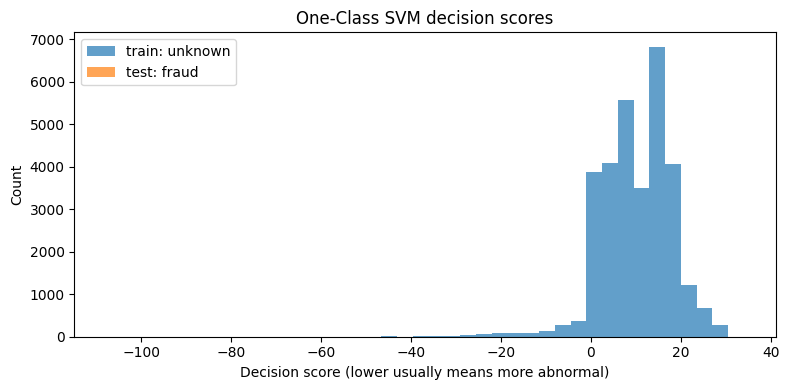

In [11]:
ocsvm = OneClassSVM(
    kernel=OCSVM_KERNEL,
    nu=OCSVM_NU,
    gamma=OCSVM_GAMMA,
)

ocsvm.fit(X_train_model)

ocsvm_train_pred = ocsvm.predict(X_train_model)
ocsvm_test_pred = ocsvm.predict(X_test_model)

ocsvm_train_score = ocsvm.decision_function(X_train_model).ravel()
ocsvm_test_score = ocsvm.decision_function(X_test_model).ravel()

ocsvm_result = pd.DataFrame({
    "model": ["OneClassSVM"],
    "rule": ["predict == -1"],
    "train_flagged_rate": [(ocsvm_train_pred == -1).mean()],
    "test_flagged_rate": [(ocsvm_test_pred == -1).mean()],
})

display(ocsvm_result)

show_hist(
    ocsvm_train_score,
    ocsvm_test_score,
    title="One-Class SVM decision scores",
    xlabel="Decision score (lower usually means more abnormal)",
)

## 7. Put the two models side by side

Since the test set here is **all fraud by construction**, the `test_flagged_rate` is basically:

> how much of the fraud-only set gets treated as abnormal

That is useful, but it is **not** a full real-world evaluation, because we still do not have a clean labeled normal test set here.

In [12]:
comparison = pd.concat([kmeans_result, ocsvm_result], ignore_index=True)
comparison["train_flagged_rate"] = comparison["train_flagged_rate"].round(4)
comparison["test_flagged_rate"] = comparison["test_flagged_rate"].round(4)

display(comparison)

,model,rule,train_flagged_rate,test_flagged_rate
0,KMeans,nearest distance > train q=0.99,0.0100,1.0
1,OneClassSVM,predict == -1,0.0499,1.0


## 8. A couple of notes before over-interpreting the result

A few things are worth keeping in mind here:

- `unknown` does **not** automatically mean clean / normal. It just means unlabeled.
- if the unknown set already contains a decent amount of hidden fraud, both models may learn a blurred version of "normal".
- K-Means is mainly useful here for structure and rough distance-based screening.
- One-Class SVM is a more direct anomaly detector, but it can be sensitive to scaling and feature choices.
- if the fraud rows are not well separated from unknown, that does not necessarily mean the models are bad. It may just mean the feature space is not separating them clearly enough.

If needed, the next thing I would try is one of these:
- Isolation Forest
- Local Outlier Factor
- autoencoder-style reconstruction models